In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,class_likelihood_ratios,roc_auc_score,roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Project_Logistic_reg\Loan_default.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\OneDrive\\Desktop\\python\\Machine learning\\Project_Logistic_reg\\Loan_default.csv'

In [ ]:
df.head(5)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [ ]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


In [ ]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [ ]:
df.drop('LoanID',axis=1,inplace=True)

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [ ]:
df.select_dtypes(include='object')

,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,Master's,Full-time,Married,No,No,Other,Yes
2,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,High School,Full-time,Married,No,No,Business,No
4,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No
...,...,...,...,...,...,...,...
255342,Bachelor's,Full-time,Married,No,No,Other,No
255343,High School,Part-time,Divorced,No,No,Home,No
255344,High School,Self-employed,Married,Yes,Yes,Auto,Yes
255345,High School,Part-time,Single,Yes,Yes,Other,No


In [ ]:
for i in df.select_dtypes(include='object').columns:
    df[i]=df[i].str.lower()
    df[i]=df[i].str.strip()

In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].unique())

["bachelor's" "master's" 'high school' 'phd']
['full-time' 'unemployed' 'self-employed' 'part-time']
['divorced' 'married' 'single']
['yes' 'no']
['yes' 'no']
['other' 'auto' 'business' 'home' 'education']
['yes' 'no']


In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())

Education
bachelor's     64366
high school    63903
master's       63541
phd            63537
Name: count, dtype: int64
EmploymentType
part-time        64161
unemployed       63824
self-employed    63706
full-time        63656
Name: count, dtype: int64
MaritalStatus
married     85302
divorced    85033
single      85012
Name: count, dtype: int64
HasMortgage
yes    127677
no     127670
Name: count, dtype: int64
HasDependents
yes    127742
no     127605
Name: count, dtype: int64
LoanPurpose
business     51298
home         51286
education    51005
other        50914
auto         50844
Name: count, dtype: int64
HasCoSigner
yes    127701
no     127646
Name: count, dtype: int64


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


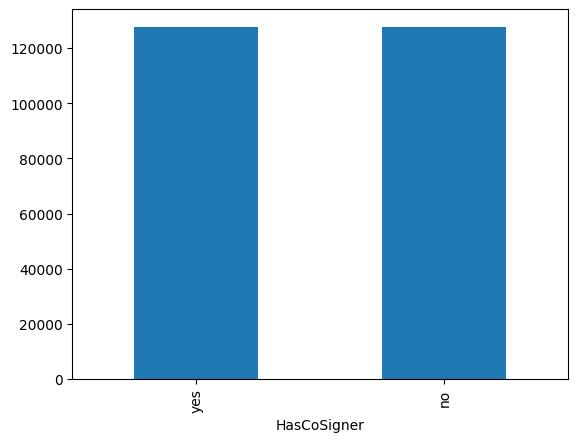

In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts().plot(kind='bar'))

In [ ]:
df.select_dtypes(exclude='object').columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
      dtype='object')

In [ ]:
numerical_feature=['Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

In [ ]:
for i in numerical_feature:
    print(df.groupby('Default')[i].mean())

Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64
Default
0    125353.656017
1    144515.311469
Name: LoanAmount, dtype: float64
Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64
Default
0    60.764721
1    50.235457
Name: MonthsEmployed, dtype: float64
Default
0    2.489566
1    2.588338
Name: NumCreditLines, dtype: float64
Default
0    13.176994
1    15.896227
Name: InterestRate, dtype: float64
Default
0    36.022544
1    36.051394
Name: LoanTerm, dtype: float64
Default
0    0.498602
1    0.512467
Name: DTIRatio, dtype: float64


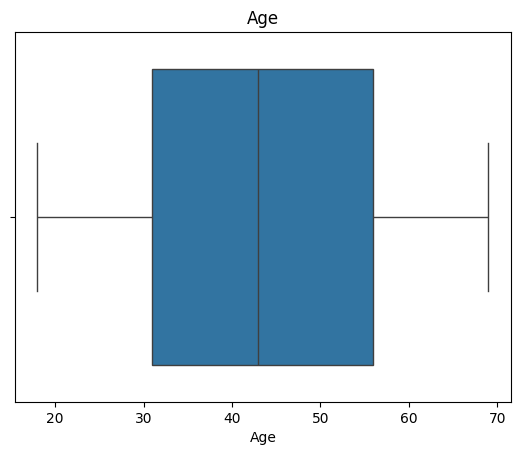

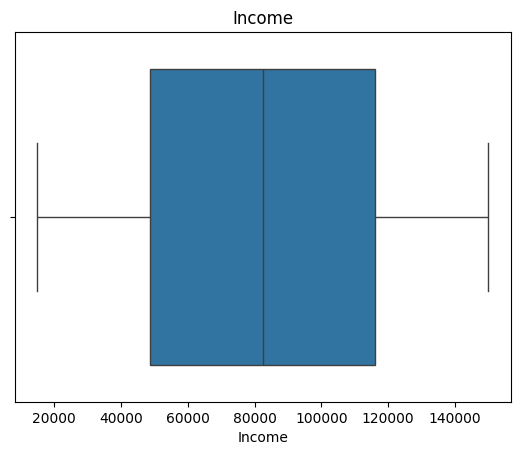

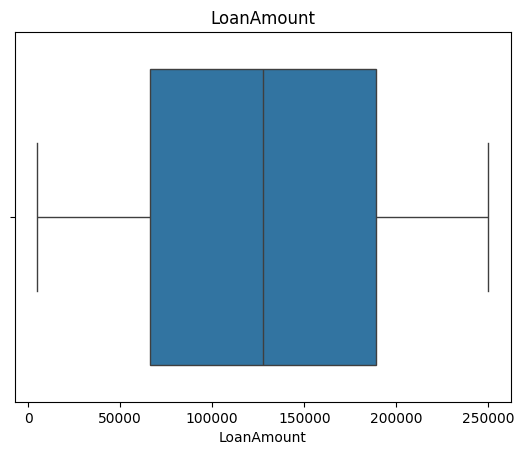

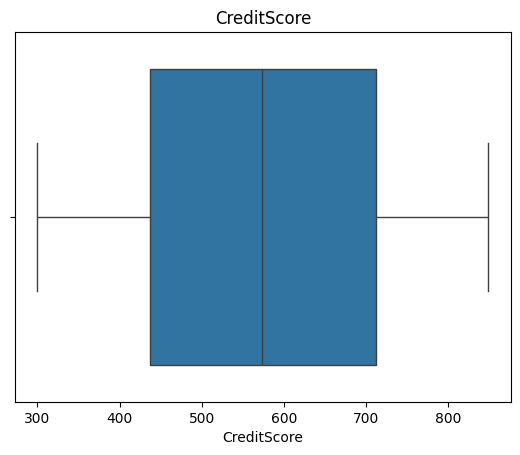

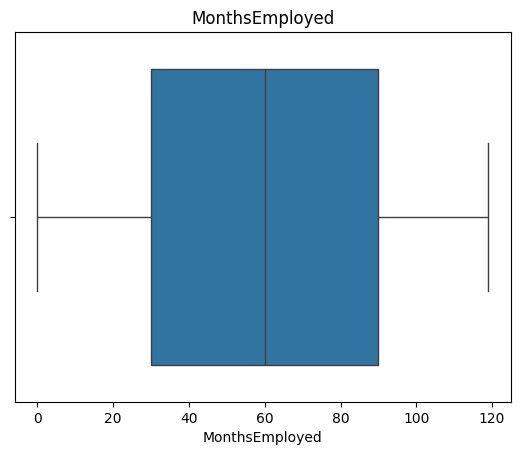

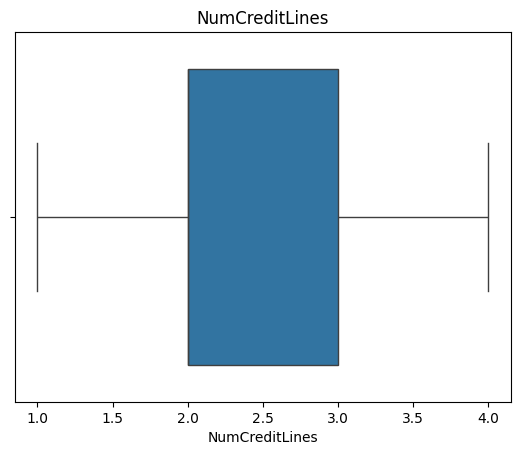

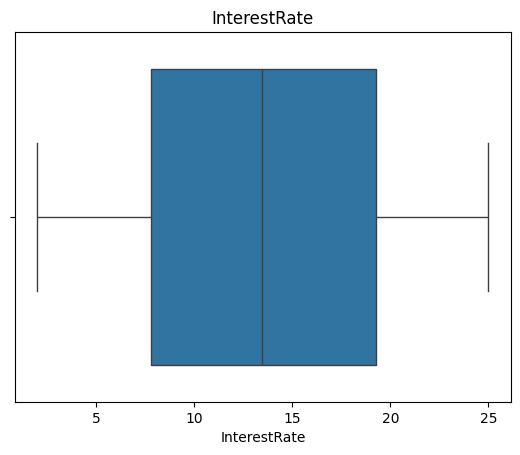

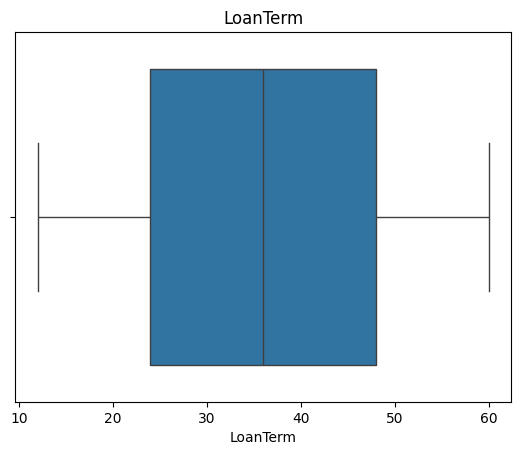

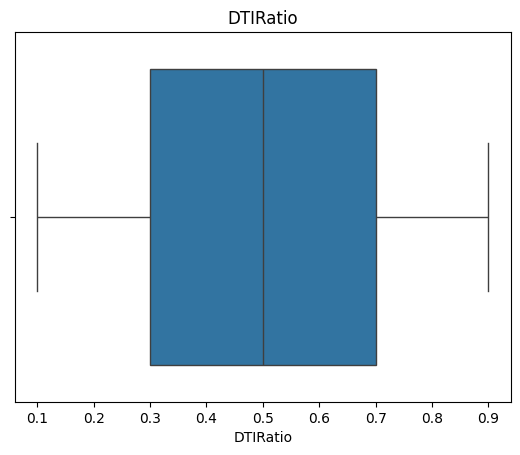

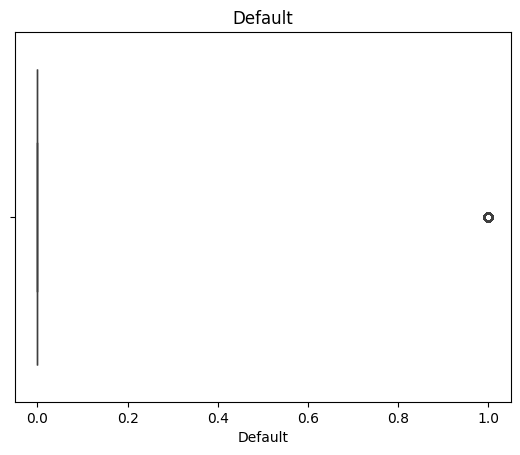

In [ ]:
num_features = df.select_dtypes(include=['number']).columns
cat_features = df.select_dtypes(include=['object']).columns

# Example imputation:
for col in num_features:
    df[col].fillna(df[col].median(),inplace=True)
for col in cat_features:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 5. Outlier check (optional)
for col in num_features:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    # If extreme

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,bachelor's,full-time,divorced,yes,yes,other,yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,master's,full-time,married,no,no,other,yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,master's,unemployed,divorced,yes,yes,auto,no,1
3,32,31713,44799,743,0,3,7.07,24,0.23,high school,full-time,married,no,no,business,no,0
4,60,20437,9139,633,8,4,6.51,48,0.73,bachelor's,unemployed,divorced,no,yes,auto,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,bachelor's,full-time,married,no,no,other,no,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,high school,part-time,divorced,no,no,home,no,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,high school,self-employed,married,yes,yes,auto,yes,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,high school,part-time,single,yes,yes,other,no,0


In [ ]:
df.select_dtypes(include='object').columns

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

Education_encoder=LabelEncoder()
EmploymentType_encoder=LabelEncoder()
MaritalStatus_encoder=LabelEncoder()
HasMortgage_encoder=LabelEncoder()
HasDependents_encoder=LabelEncoder()
LoanPurpose_encoder=LabelEncoder()
HasCoSigner_encoder=LabelEncoder()



In [ ]:
df['Education']=Education_encoder.fit_transform(df['Education'])
df['EmploymentType']=Education_encoder.fit_transform(df['EmploymentType'])
df['MaritalStatus']=Education_encoder.fit_transform(df['MaritalStatus'])
df['HasCoSigner']=Education_encoder.fit_transform(df['HasCoSigner'])
df['HasDependents']=Education_encoder.fit_transform(df['HasDependents'])
df['LoanPurpose']=Education_encoder.fit_transform(df['LoanPurpose'])
df['HasMortgage']=Education_encoder.fit_transform(df['HasMortgage'])

In [ ]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,0,0,1,0,0,4,0,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,1,1,0,0,0,3,0,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,1,2,1,1,1,0,1,0
255345,42,85109,60575,809,40,1,20.90,48,0.44,1,1,2,1,1,4,0,0


In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]


In [ ]:
x

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,0,0,1,0,0,4,0
255343,32,51953,189899,511,14,2,11.55,24,0.21,1,1,0,0,0,3,0
255344,56,84820,208294,597,70,3,5.29,60,0.50,1,2,1,1,1,0,1
255345,42,85109,60575,809,40,1,20.90,48,0.44,1,1,2,1,1,4,0


In [ ]:
y

0         0
1         0
2         1
3         0
4         0
         ..
255342    0
255343    1
255344    0
255345    0
255346    0
Name: Default, Length: 255347, dtype: int64

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()   # ✔️ object created


x_train_scaled=scaler.fit_transform(x_train)

x_test_scaled=scaler.transform(x_test)

log_reg=LogisticRegression(max_iter=1000,class_weight='balanced')


param_grid={
    'C':[0.01,0.1,1,10],
    'penalty':['l1','l2'],
    'solver':['ibfgs','liblinear']
}

model=GridSearchCV(log_reg,param_grid=param_grid,cv=5)

In [ ]:
log_reg.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred=log_reg.predict(x_test_scaled)

In [ ]:
model.fit(x_train_scaled,y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['ibfgs', 'liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [ ]:
model.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

In [ ]:
log_reg=LogisticRegression(C=1,penalty='l2',solver='lbfgs')
log_reg.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred=log_reg.predict(x_test_scaled)


In [ ]:
y_train_pred=log_reg.predict(x_train_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_train_pred))
print(accuracy_score(y_test,y_pred))

0.8850384526892406
0.8858625416095555


In [ ]:
y_prob=log_reg.predict_proba(x_test_scaled)[:,1]

In [ ]:
y_prob

array([0.03346222, 0.03602307, 0.08035898, ..., 0.08917685, 0.07898573,
       0.03511524])

In [ ]:
fpr,tpr,thre=roc_curve(y_test,y_prob)

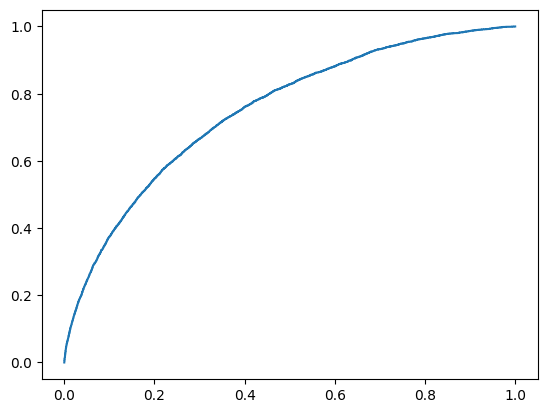

In [ ]:
plt.plot(fpr,tpr)

In [ ]:
import numpy as np

In [ ]:
import numpy as np
vth=thre[np.argmax(tpr-fpr)]
y_prob

array([0.03346222, 0.03602307, 0.08035898, ..., 0.08917685, 0.07898573,
       0.03511524])

In [ ]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [ ]:
y_pred_new=list(map(lambda x:1 if x>0.11 else 0,y_prob))

In [ ]:
confusion_matrix(y_test,y_pred_new)

array([[29338, 15832],
       [ 1666,  4234]])

In [ ]:
print(classification_report(y_test,y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.65      0.77     45170
           1       0.21      0.72      0.33      5900

    accuracy                           0.66     51070
   macro avg       0.58      0.68      0.55     51070
weighted avg       0.86      0.66      0.72     51070



In [ ]:
import joblib
import joblib
Education_encoder=LabelEncoder()
EmploymentType_encoder=LabelEncoder()
MaritalStatus_encoder=LabelEncoder()
HasMortgage_encoder=LabelEncoder()
LoanPurpose_encoder=LabelEncoder()
HasCoSigner_encoder=LabelEncoder()
HasDependents_encoder=LabelEncoder()

In [ ]:
joblib.dump(log_reg,'Logistic_reg_3')
joblib.dump(Education_encoder,'Education_encoder.pkl')
joblib.dump(EmploymentType_encoder,'EmploymentType_encoder.pkl')
joblib.dump(MaritalStatus_encoder,'MaritalStatus_encoder.pkl')
joblib.dump(HasMortgage_encoder,'HasMortgage_encoder.pkl')
joblib.dump(LoanPurpose_encoder,'LoanPurpose_encoder.pkl')
joblib.dump(HasCoSigner_encoder,'HasCoSigner_encoder.pkl')
joblib.dump(HasDependents_encoder,'HasDependents_encoder.pkl')
